# Naive Bayes

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score


In [18]:
# Cargar el archivo
df = pd.read_csv('violencia_unite_data.csv')

# Convertir 'CONDUCENTE' a binario: 1.0 -> 1, 2.0 o 9.0 -> 0
df['CONDUCENTE'] = df['CONDUCENTE'].replace({2.0: 0, 9.0: 0})

# Eliminar filas con valores nulos en la variable objetivo
df = df.dropna(subset=['CONDUCENTE'])

df.value_counts('CONDUCENTE')

CONDUCENTE
1.0    14623
0.0     8038
Name: count, dtype: int64

In [19]:
# Variable objetivo
y = df['CONDUCENTE']

# Selección de características
X = df[[
    'REP_DEP', 'REP_MUNI', 'VIC_SEXO', 'VIC_EDAD',
    'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET',
    'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP',
    'HEC_DEP', 'HEC_MUNI', 'HEC_AREA'
]]


In [20]:
# Separar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

# Crear transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'  # Deja pasar columnas numéricas tal cual
)


In [21]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#pipeline y modelo
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])


# entrenar el modelo
pipeline.fit(X_train, y_train)

# Predicciones
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Analizar el modelo
print("Error cuadrático medio (MSE) en entrenamiento:", mean_squared_error(y_train, y_pred_train))
print("Error cuadrático medio (MSE) en prueba:", mean_squared_error(y_test, y_pred_test))
print("R^2 en entrenamiento:", r2_score(y_train, y_pred_train))
print("R^2 en prueba:", r2_score(y_test, y_pred_test))

Error cuadrático medio (MSE) en entrenamiento: 0.5188658428949691
Error cuadrático medio (MSE) en prueba: 0.5228325612177366
R^2 en entrenamiento: -1.2793714055215064
R^2 en prueba: -1.238691111259294



Matriz de confusión:
 [[1552  133]
 [2237  611]]

Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       0.41      0.92      0.57      1685
         1.0       0.82      0.21      0.34      2848

    accuracy                           0.48      4533
   macro avg       0.62      0.57      0.45      4533
weighted avg       0.67      0.48      0.42      4533

Matriz de confusión
 [[1552  133]
 [2237  611]]
Accuracy:  0.4771674387822634
Precision:  0.4771674387822634
Recall:  0.4771674387822634
F1-score:  0.4771674387822634


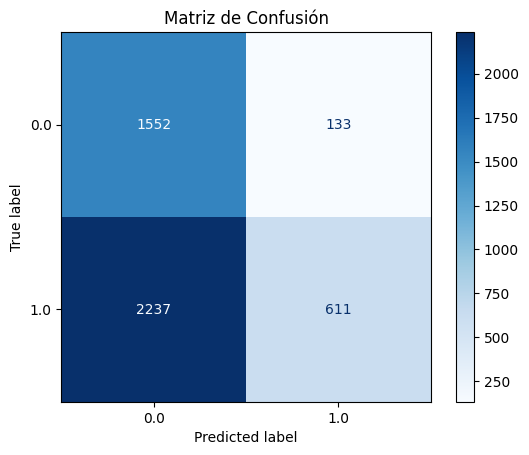

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_test))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average='micro')
recall = recall_score(y_test, y_pred_test, average='micro')
f1 = f1_score(y_test, y_pred_test, average='micro')

print('Matriz de confusión\n', cm)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

Al observar los resultados el error cuadrático medio (MSE) tanto para prueba y entrenamiento los valores se mantienen entre 0.51 y 0.52 de nedudad del cuadrado de predicción. Que los resultados esten cercanos a 0.5, nos incica que el modelo parece predecir de manera aleatoria. 

Acerca del R^2 los resultados de entrenamiento y prueba son negativos, cuando el resultado es igual que 0, el modelo no explica mejor que predecir la medida. Pero cuando los resultados son menores que 0 es porque el modelo esta peor que predecir la media. Por lo tanto, el modelo no esta tomando patrones utiles para la predicción.  Lo que se puede probar es con submuestreo para saber si mejora.


Y lo que nos indica esta matriz de confusión, es que el modelo predice muy bien los casos no conducentes, pero tiene muchos errores al predecir los casos conducentes.  

## Prueba con submuestreo

In [23]:
#separar por clase
df_1 = df[df['CONDUCENTE'] == 1]
df_0 = df[df['CONDUCENTE'] == 0]

# Submuestreo de la clase mayoritaria (1.0)
df_1_downsampled = df_1.sample(len(df_0), random_state=42)

# Unir los conjuntos balanceados
df_balanced = pd.concat([df_1_downsampled, df_0])

# Mezclar el dataframe
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

df_balanced.value_counts('CONDUCENTE')

CONDUCENTE
0.0    8038
1.0    8038
Name: count, dtype: int64

In [24]:
# Variable objetivo
y = df_balanced['CONDUCENTE']

# Selección de características
X = df_balanced[[
    'REP_DEP', 'REP_MUNI', 'VIC_SEXO', 'VIC_EDAD',
    'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET',
    'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP',
    'HEC_DEP', 'HEC_MUNI', 'HEC_AREA'
]]


In [25]:
# Separar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

# Crear transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'  # Deja pasar columnas numéricas tal cual
)


In [26]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#pipeline y modelo
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])


# entrenar el modelo
pipeline.fit(X_train, y_train)

# Predicciones
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Analizar el modelo
print("Error cuadrático medio (MSE) en entrenamiento:", mean_squared_error(y_train, y_pred_train))
print("Error cuadrático medio (MSE) en prueba:", mean_squared_error(y_test, y_pred_test))
print("R^2 en entrenamiento:", r2_score(y_train, y_pred_train))
print("R^2 en prueba:", r2_score(y_test, y_pred_test))

Error cuadrático medio (MSE) en entrenamiento: 0.3812597200622084
Error cuadrático medio (MSE) en prueba: 0.40516169154228854
R^2 en entrenamiento: -0.5250720781733746
R^2 en prueba: -0.6212110660779864



Matriz de confusión del remuestreo:
 [[ 457 1121]
 [ 182 1456]]

Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       0.72      0.29      0.41      1578
         1.0       0.56      0.89      0.69      1638

    accuracy                           0.59      3216
   macro avg       0.64      0.59      0.55      3216
weighted avg       0.64      0.59      0.55      3216

Matriz de confusión
 [[ 457 1121]
 [ 182 1456]]

ROC AUC Score: 0.5892479932403887
Accuracy:  0.5948383084577115
Precision:  0.5948383084577115
Recall:  0.5948383084577115
F1-score:  0.5948383084577115


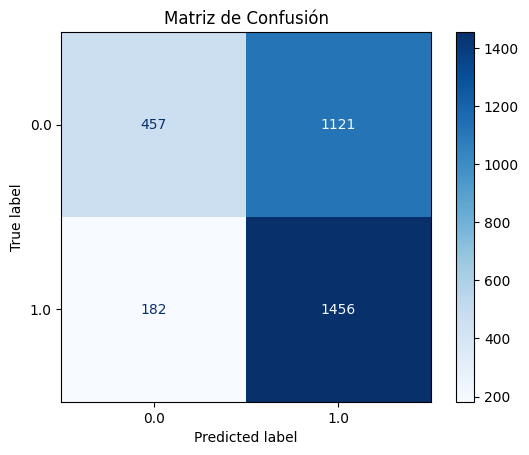

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, f1_score

print("\nMatriz de confusión del remuestreo:\n", confusion_matrix(y_test, y_pred_test))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average='micro')
recall = recall_score(y_test, y_pred_test, average='micro')
f1 = f1_score(y_test, y_pred_test, average='micro')

print('Matriz de confusión\n', cm)

print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_test))
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

Al hacer el remuestreo, se puede ver que se obtuvieron mejores resultados como en el recall que ahora tiene 0.89 en la clase 1. Entonces, ahora el modelo detecta la mayoría de los casos conducentes. Al igual el F1 parece que en los datos reales esta bien. Al balancear los datos ayudo a que el modelo no ignore los positivos. 

Sin embargo, el recall en la clase 0, es muy bajo y el modelo se confunde mucho y predice falsos positivos. También, la prediccion para la clase 1 bajo a 0.56 entonces casi la mitas de las veces que dice ser violencia esta equivocado.  También el R^2 sigue siendo negativo y el accuracy es de 0.59.

Con el remuestreo prioriza los casos de violencia, pero sacrifica la exactitud y la precisión. 
Y lo que se puede ver en la matriz de confusión es que el modelo es bueno prediciendo casos conducentes, sin embargo, es malo prediciendo los no conducentes.  

Lo que se puede probar es ver la curva ROC y cross validation para evaluar el desempe;o del modelo.


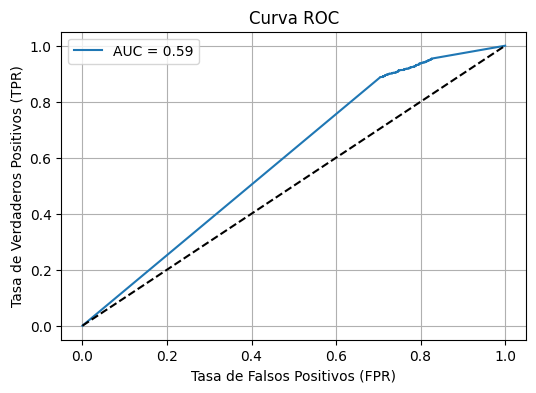

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_fscore_support, ConfusionMatrixDisplay, RocCurveDisplay
# Obtener probabilidades de clase positiva
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Visualización
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Línea base
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

El gráfico de la curva ROC, se puede ver el AUC de 0.59, que nos indica que el modelo le cuesta distinguir entre clases. Además, este muestra la relación entre la tasa de verdaderos positivos y falsos positivos. La línea negra representa un modelo aleatorio de 0.5, al ver la comparación se puede decir que el modelo es ligeramente mejor que adivinar al azar. 

Reporte de clasificación (Cross-Validation):
              precision    recall  f1-score   support

         0.0       0.72      0.29      0.41      8038
         1.0       0.56      0.89      0.68      8038

    accuracy                           0.59     16076
   macro avg       0.64      0.59      0.55     16076
weighted avg       0.64      0.59      0.55     16076

Matriz de confusión:
[[2317 5721]
 [ 898 7140]]
Accuracy:  0.5882682259268475
Precision:  0.5882682259268475
Recall:  0.5882682259268475
F1-score:  0.5882682259268475


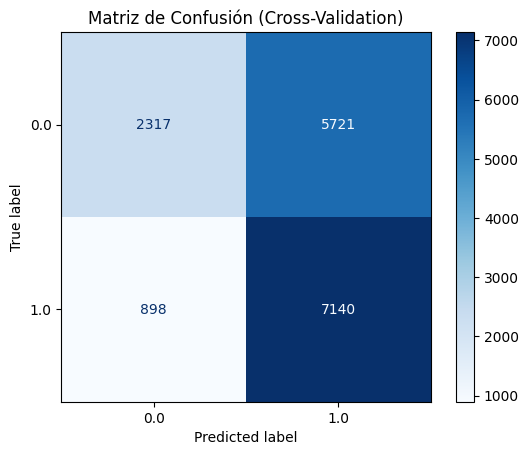

In [29]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), X.select_dtypes(include='object').columns)
    ],
    remainder='passthrough'
)


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', GaussianNB())
])

# Predicción con validación cruzada
y_pred_cv = cross_val_predict(pipeline, X, y, cv=5)

# Reporte de clasificación
print("Reporte de clasificación (Cross-Validation):")
print(classification_report(y, y_pred_cv))

# Matriz de confusión
print("Matriz de confusión:")
print(confusion_matrix(y, y_pred_cv))

accuracy = accuracy_score(y, y_pred_cv)
precision = precision_score(y, y_pred_cv, average='micro')
recall = recall_score(y, y_pred_cv, average='micro')
f1 = f1_score(y, y_pred_cv, average='micro')


print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

cm = confusion_matrix(y, y_pred_cv)
# Fit the pipeline to access the classes_
pipeline.fit(X_train, y_train)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.named_steps['clf'].classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión (Cross-Validation)')
plt.show()


Al igual que en la segunda prueba, el modelo es mejor prediciendo casos conducentes. Pero también, predice violencia en dónde no la hay y falla en detectar casos en donde no hay violencia. Y eso se puede ver en la matriz de confusión.  

Con cross validation y normalizacion

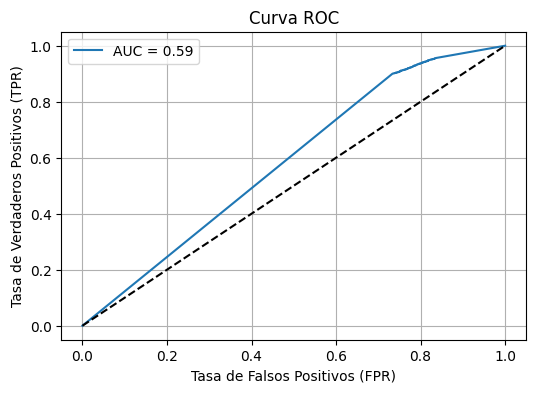

In [30]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler

# Columnas categóricas
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

#normalizar 
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', GaussianNB())
])


# Obtener probabilidades (para curva ROC)
y_proba_cv = cross_val_predict(pipeline, X, y, cv=5, method='predict_proba')

# Extraer probas clase 1
y_scores = y_proba_cv[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y, y_scores)
auc = roc_auc_score(y, y_scores)

# Visualización
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Línea base
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()


El grafico de la curva ROC, se puede ver el AUC de 0.59, el mismo resultado antes que cross validation y normalizar los datos. Esto nos indica que el modelo le cuesta distinguir entre clases. Ademas, este muestra la relacion entre la tasa de verdaderos positivos y falsos positivos.La linea negra representa un modelo aleatorio de 0.5, al ver la comparacion se puede decir que el modelo es ligeramente mejor que adivinar al azar.

Entonces, se puede decir que Naive Bayes no es buen modelo para este problema. Ya que, Naive Bayes asume independencia entre las variables, lo cual raramente cumple en datos de la violencia intrafamiliar. Este modelo, al ser algo simple , no puede capturar las complejidades de este problema. Y la distribución Gausiana no se adapta bien a muchas variables categoricas.